In [3]:
from PIL import Image
import io, tempfile, urllib, requests, os, time
import re
import glob
import json
import base64
import random
import zipfile
import urllib.parse
import pandas as pd
from tqdm import tqdm
from docx import Document
from openai import OpenAI
import unicodedata
import math
import numpy as np

In [2]:
# Required Environment Variables
os.environ["OPENAI_API_KEY"] = "YOUR_OPENAI_API_KEY"
os.environ["GITHUB_TOKEN"] = "YOUR_GITHUB_TOKEN"
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
GITHUB_TOKEN   = os.getenv("GITHUB_TOKEN")

client = OpenAI(api_key=OPENAI_API_KEY)

In [3]:
# Basic Parameters 
FOLDER_PATH = r"C:\Users\wangy\Downloads\word_doc-20250922T105705Z-1-001\word_doc"
MODEL_NAME  = "gpt-4o"

# Batch Control
BRANCH = "main"        
INTERVAL_SEC = (20, 35)  # Random wait time between articles (to prevent 429 errors), in seconds, range tuple

# Output filenames (saved per batch)
BATCH_OUT_DIR = "batch_outputs" # Batch output directory
FINAL_MERGED  = "merged_result.xlsx"

# GitHub image hosting
REPO_OWNER = "Yanjun0526"
REPO_NAME  = "word-images-3"

# Image size and quantity control
MAX_IMAGE_BYTES = 9_000_000  

In [4]:
def github_api_headers():
    return {
        "Authorization": f"token {GITHUB_TOKEN}",
        "Accept": "application/vnd.github.v3+json"
    }

def repo_exists(owner: str, repo: str) -> bool:
    url = f"https://api.github.com/repos/{owner}/{repo}"
    r = requests.get(url, headers=github_api_headers())
    return r.status_code == 200

def create_repo(owner: str, repo: str):
     # Create and auto_init, ensuring the main branch exists
    url = "https://api.github.com/user/repos"
    payload = {"name": repo, "private": False, "auto_init": True}
    r = requests.post(url, headers=github_api_headers(), json=payload)
    if r.status_code in (200, 201):
        print(f"Repository created: {owner}/{repo}")
        # Upload a README to ensure the branch and content exist
        upload_file_to_github(owner, repo, "README.md",
                              b"# Auto initialized repository",
                              message="init repo")
        return True
    elif r.status_code == 422 and "already exists" in r.text:
        print("Repository may already exist")
        return True
    else:
        raise RuntimeError(f"Failed to create repository: {r.status_code} {r.text}")

def sanitize_filename(name: str) -> str:
    """Make filenames safe for GitHub/CDN use (remove non-ASCII & special chars)"""
    # Normalize Unicode and remove accents
    name = unicodedata.normalize("NFKD", name)
    # Keep only ASCII letters, digits, underscores, and hyphens
    name = re.sub(r"[^A-Za-z0-9_.-]", "_", name)
    # Limit length to 150 chars
    return name[:150]

def upload_file_to_github(owner: str, repo: str, path: str, content_bytes: bytes,
                          message: str = "upload via script", branch: str = BRANCH) -> str:
    """
    Upload or update files to the specified GitHub path.
    Return the jsDelivr CDN URL (GPT can reliably read it).
    """
    path = urllib.parse.quote(path)
    b64_content = base64.b64encode(content_bytes).decode("utf-8")

# Check if a file already exists to include its SHA
    sha = None
    check_url = f"https://api.github.com/repos/{owner}/{repo}/contents/{urllib.parse.quote(path)}"
    sha_resp = requests.get(check_url, headers=github_api_headers())
    if sha_resp.status_code == 200 and isinstance(sha_resp.json(), dict):
        sha = sha_resp.json().get("sha")

    put_url = f"https://api.github.com/repos/{owner}/{repo}/contents/{urllib.parse.quote(path)}"
    payload = {"message": message, "content": b64_content, "branch": branch}
    if sha:
        payload["sha"] = sha

    r = requests.put(put_url, headers=github_api_headers(), json=payload)
    if r.status_code in (200, 201):
        cdn_url = f"https://cdn.jsdelivr.net/gh/{owner}/{repo}@{branch}/{urllib.parse.quote(path)}"
        print(f"✅ Uploaded {os.path.basename(path)} → {cdn_url}")   # ensure visible
        return cdn_url
    raise RuntimeError(f"Upload failed: {r.status_code} {r.text}")

In [5]:
def extract_docx(filepath: str):
    """Extract titles, full text content, image binaries (list)"""
    doc = Document(filepath)
    title = os.path.splitext(os.path.basename(filepath))[0]
    content = "\n".join(p.text for p in doc.paragraphs if p.text.strip())
    word_count = len(content)

    images = []
    with zipfile.ZipFile(filepath, "r") as z:
        for file in z.namelist():
            if file.startswith("word/media/"):
                img_bytes = z.read(file)
                ext = os.path.splitext(file)[1].lower()
                mime = "image/png" if ext == ".png" else "image/jpeg"
                images.append((os.path.basename(file), img_bytes, mime))

    has_image = "Yes" if images else "No"
    return title, content, word_count, has_image, images

def call_gpt_with_retry(content_parts, model="gpt-4o", max_retries=6, base_delay=10):
    """Call GPT with retry on transient errors (CDN sync, rate limits, etc.)"""
    for attempt in range(1, max_retries + 1):
        try:
            return client.chat.completions.create(
                model=model,
                messages=[{"role": "user", "content": content_parts}],
                temperature=0.3
            )  
        except Exception as e:
            err_str = str(e)
            # Retryable error types
            if any(key in err_str for key in [
                "invalid_image_url",
                "Error while downloading",
                "rate_limit_exceeded",
                "Request too large",
                "Bad gateway",
                "Service unavailable"
            ]):
                delay = base_delay * (2 ** (attempt - 1)) + random.uniform(0, 2)
                print(f"⚠️ GPT call failed (attempt {attempt}/{max_retries}): {err_str}")
                print(f"⏳ Retrying in {delay:.1f}s...")
                time.sleep(delay)
                continue
            # Not retryable → raise
            raise
    raise RuntimeError(f"❌ GPT call failed after {max_retries} retries.")

def upload_images_with_conversion(fname, images, subdir):
    images = images[:30] 
    image_urls = []
    for (orig_name, img_bytes, mime) in images:
        if len(img_bytes) > MAX_IMAGE_BYTES:
            print(f"⚠️ Skipping large image {orig_name} ({len(img_bytes)/1e6:.1f} MB)")
            continue

        safe = sanitize_filename(orig_name)
        remote_path = f"{subdir}/{safe}"
        ext = os.path.splitext(orig_name)[1].lower()
        temp_converted = None

        if ext in (".wmf", ".emf"):
            try:
                print(f"🌀 Converting {orig_name} ({ext.upper()}) → PNG ...")
                with tempfile.NamedTemporaryFile(suffix=ext, delete=False) as tmp_emf:
                    tmp_emf.write(img_bytes)
                    tmp_emf.flush()
                with Image.open(tmp_emf.name) as img:
                    with tempfile.NamedTemporaryFile(suffix=".png", delete=False) as tmp_png:
                        img.save(tmp_png, format="PNG")
                        tmp_png.flush()
                        with open(tmp_png.name, "rb") as f:
                            img_bytes = f.read()
                            safe = safe.replace(ext, ".png")
                            remote_path = f"{subdir}/{safe}"
                            temp_converted = tmp_png.name
            except Exception as e:
                print(f"⚠️ Failed to convert {orig_name}: {e}")
                continue
            finally:
                try:
                    os.remove(tmp_emf.name)
                except Exception:
                    pass

        remote_path = urllib.parse.quote(remote_path)
        for attempt in range(3):
            try:
                url = upload_file_to_github(REPO_OWNER, REPO_NAME, remote_path, img_bytes,
                                            message=f"upload {fname} - {orig_name}")
                r = requests.head(url, timeout=5)
                if r.status_code != 200:
                    raise Exception(f"Inaccessible URL {url}")
                image_urls.append(url)
                #print(f"✅ Uploaded {os.path.basename(remote_path)} → {url}")
                break
            except Exception as e:
                print(f"⚠️ Upload failed {orig_name} (attempt {attempt+1}/3): {e}")
                time.sleep(10)
        else:
            print(f"❌ Skipping {orig_name} after 3 failed attempts.")

        if temp_converted and os.path.exists(temp_converted):
            try:
                os.remove(temp_converted)
                print(f"🧹 Cleaned up temp file: {temp_converted}")
            except Exception as cleanup_err:
                print(f"⚠️ Failed to clean up temp file: {cleanup_err}")

    return image_urls

def wait_for_network():
    """检测网络是否恢复（Ping OpenAI 服务器）"""
    while True:
        try:
            socket.create_connection(("api.openai.com", 443), timeout=5)
            print("🌐 网络已恢复，继续任务。")
            break
        except Exception:
            print("⚠️ 网络中断或 VPN 掉线，等待 30 秒后重试...")
            time.sleep(30)

def wait_for_cdn_ready(image_urls, timeout=120):
    """Wait until the first uploaded image is available on jsDelivr."""
    if not image_urls:
        return
    test_url = image_urls[0]
    start = time.time()
    while time.time() - start < timeout:
        try:
            r = requests.head(test_url, timeout=5)
            if r.status_code == 200:
                print("✅ CDN synced and reachable.")
                return
        except Exception:
            pass
        print("🕒 Waiting 20s for CDN sync...")
        time.sleep(20)
    print("⚠️ CDN not ready after waiting, continuing anyway.")

In [6]:
def analyze_title_only(title: str):
    """
    使用 GPT-4o 对文档标题进行主题分析，返回两个可能的主题。
    """
    prompt = f"""
你是一名中文文本主题建模专家。
请仅根据下列标题文字本身的内容来判断文章主题。
请忽略任何品牌名、公司名、地名或现实世界背景知识，
不要利用对“名匠”等品牌的认知。
背景信息：名匠是一家普通公司名。
请给出两个最有可能的主题类别，用简短中文表达。

输出严格 JSON：
{{
  "top_2_title_topics": ["主题1", "主题2"]
}}

标题：{title}
""".strip()

    try:
        resp = client.chat.completions.create(
            model="gpt-4o",
            messages=[{"role": "user", "content": prompt}],
            temperature=0.3
        )
        raw = resp.choices[0].message.content.strip()
        m = re.search(r"\{.*\}", raw, re.S)
        return json.loads(m.group(0)).get("top_2_title_topics", []) if m else []
    except Exception as e:
        print(f"⚠️ Title analysis failed: {e}")
        return []


def analyze_title_and_content(title: str, content: str, image_urls: list = None, retry: bool = False, max_retries: int = 6):
    """
    使用 GPT-4o 对标题 + 正文 + 图片 进行联合主题建模，
    返回三个最有可能的主题（最多使用前 30 张图片）。
    """
    prompt = f"""
你是一名中文文本主题建模专家。
请根据以下文章标题、正文内容以及所附图片，综合判断主题。
请输出三个最有可能的主题类别，用简短中文表达。

输出严格 JSON：
{{
  "top_3_combined_topics": ["主题1", "主题2", "主题3"]
}}

标题：{title}
正文：{content[:4000]}{"..." if len(content) > 4000 else ""}
""".strip()

    try:
        # GPT 输入内容
        content_parts = [{"type": "text", "text": prompt}]

        # 限制图片数量（最多 30 张）
        if image_urls:
            for url in image_urls[:30]:
                content_parts.append({
                    "type": "image_url",
                    "image_url": {"url": url}
                })

        if retry:
            try:
                resp = call_gpt_with_retry(content_parts, model="gpt-4o", max_retries=max_retries)
            except Exception as e:
                if "Request too large" in str(e) or "rate_limit_exceeded" in str(e):
                    print("⚠️ Too large for gpt-4o, retrying with gpt-4o-mini...")
                    resp = call_gpt_with_retry(content_parts, model="gpt-4o-mini", max_retries=max_retries)
                else:
                    raise
        else:
            resp = client.chat.completions.create(
                model="gpt-4o",
                messages=[{"role": "user", "content": content_parts}],
                temperature=0.3
            )



        # 提取 JSON
        raw = resp.choices[0].message.content.strip()
        m = re.search(r"\{.*\}", raw, re.S)
        if m:
            try:
                data = json.loads(m.group(0))
                return data.get("top_3_combined_topics", [])
            except Exception as e:
                print(f"⚠️ JSON parse failed: {e}")
                return []
        else:
            return []

    except Exception as e:
        print(f"⚠️ Content analysis failed: {e}")
        return []


def process_single_docx(file_path: str):
    """
    Process a single .docx file:
    1. Extract title, text, and images;
    2. Upload up to 30 images to GitHub;
    3. Analyze title and full content (with images);
    4. Save one record of results.
    """
    # FAILED_FILES = []

    os.makedirs(BATCH_OUT_DIR, exist_ok=True)
    fname = os.path.basename(file_path)

    try:
        # Extract information
        title, content, word_count, has_image, images = extract_docx(file_path)

        # Upload images to GitHub (limit to 30)
        image_urls = []
        if has_image and images:
            subdir = sanitize_filename(os.path.splitext(fname)[0])
            images = images[:30]  # limit to 30
            image_urls = upload_images_with_conversion(fname, images, subdir)
            print(f"✅ Uploaded {len(image_urls)} images to GitHub.")
            
        if image_urls:
            wait_for_cdn_ready(image_urls)

        # Run analysis (title + content)
        title_topics = analyze_title_only(title)
        combined_topics = analyze_title_and_content(title, content, image_urls=image_urls, retry=True)

                
        # Collect results
        result = {
            "Filename": fname,
            "Title": title,
            "WordCount": word_count,
            "HasImage": has_image,
            "NumImages": len(image_urls),
            "ImageURLs": ", ".join(image_urls),
            "Title_Topics": ", ".join(title_topics),
            "Combined_Topics": ", ".join(combined_topics),
        }
        
        # if not title_topics or not combined_topics:
        #     FAILED_FILES.append(fname)
        #     print(f"⚠️ Incomplete analysis → {fname}")


        # Save output to Excel
        out_path = os.path.join(BATCH_OUT_DIR, f"{os.path.splitext(fname)[0]}_analysis.xlsx")
        pd.DataFrame([result]).to_excel(out_path, index=False)
        print(f"✅ Saved result → {out_path}")

        # Random delay to prevent rate limits
        time.sleep(random.uniform(*INTERVAL_SEC))

        return result

    except Exception as e:
        print(f"❌ Error processing {fname}: {e}")
        return {"Filename": fname, "Error": str(e)}


In [7]:
def process_folder_from_list(folder_path: str, filelist_df: pd.DataFrame, filename_col: str = "Filename"):
    """
    仅处理 DataFrame 中列出的文件；每个文档单独调用，不做批量输入。
    支持断点续跑、自动保存进度、网络掉线恢复。
    """
    os.makedirs(BATCH_OUT_DIR, exist_ok=True)
    
    if not repo_exists(REPO_OWNER, REPO_NAME):
        print(f"📦 Repository {REPO_OWNER}/{REPO_NAME} not found — creating...")
        create_repo(REPO_OWNER, REPO_NAME)
        
    out_path = os.path.join(BATCH_OUT_DIR, "filtered_results.xlsx")
    fail_log_path = os.path.join(BATCH_OUT_DIR, "failed_docs.txt")

    if os.path.exists(out_path):
        old_df = pd.read_excel(out_path)
        processed_files = set(old_df["Filename"].tolist())
        results = old_df.to_dict("records")
        print(f"🔁 检测到已有进度文件，已处理 {len(processed_files)} 篇文档，将跳过这些文件。")
    else:
        processed_files, results = set(), []
        
    # 过滤匹配目标文件
    targets = set(filelist_df[filename_col].astype(str).apply(lambda x: x if x.endswith(".docx") else x + ".docx"))
    all_docx = {f for f in os.listdir(folder_path) if f.endswith(".docx")}
    matched = sorted(all_docx & targets)
    missing = sorted(targets - all_docx)

    print(f"📋 目标文件数：{len(targets)}")
    print(f"✅ 匹配到：{len(matched)}")
    if missing:
        print(f"⚠️ 未找到的文件：{len(missing)} 个（示例：{missing[:5]}）")

    for idx, fname in enumerate(matched, 1):
        if fname in processed_files:
            continue  #跳过已完成文件

        print(f"\n🔍 [{idx}/{len(matched)}] 正在分析：{fname}")
        path = os.path.join(folder_path, fname)

        try:
            result = process_single_docx(path)

        except Exception as e:
            err_str = str(e).lower()
            print(f"⚠️ 处理 {fname} 时出错：{e}")

            # 网络错误
            if "connection" in err_str or "timeout" in err_str or "network" in err_str:
                wait_for_network()
                try:
                    result = process_single_docx(path)
                except Exception as e2:
                    print(f"❌ 重试失败：{e2}")
                    result = {"Filename": fname, "Error": str(e2)}
            else:
                result = {"Filename": fname, "Error": str(e)}

            # 记录失败日志
            with open(fail_log_path, "a", encoding="utf-8") as f:
                f.write(fname + "\n")

        results.append(result)

        if len(results) % 5 == 0:
            pd.DataFrame(results).to_excel(out_path, index=False)
            print(f"💾 已保存进度 → {out_path}")

        time.sleep(random.uniform(*INTERVAL_SEC))

    # if FAILED_FILES:
    #     failed_out = os.path.join(BATCH_OUT_DIR, "failed_files.xlsx")
    #     pd.DataFrame({"Failed_Files": FAILED_FILES}).to_excel(failed_out, index=False)
    #     print(f"⚠️ Recorded {len(FAILED_FILES)} failed files → {failed_out}")
    # else:
    #     print("✅ No failed files for this part.")


    pd.DataFrame(results).to_excel(out_path, index=False)
    print(f"\n🏁 全部完成，共处理 {len(results)} 篇文档。")
    print(f"📘 结果文件：{out_path}")
    if os.path.exists(fail_log_path):
        print(f"⚠️ 部分失败文件已记录于：{fail_log_path}")

    return pd.DataFrame(results)

In [8]:
# import pandas as pd

# # Step 1: Load Excel file
# filelist_df = pd.read_excel("batch_outputs/detail_filtered2.xlsx")

# # Step 2: Clean column names (remove extra spaces)
# filelist_df.columns = filelist_df.columns.str.strip()

# # Step 3: Create a NEW dataframe with only article_title
# # Convert to string and add '.docx' if missing
# unique_filenames = (
#     filelist_df["article_title"]
#     .astype(str)
#     .apply(lambda x: x if x.lower().endswith(".docx") else x + ".docx")
#     .drop_duplicates()  # remove duplicate filenames
#     .reset_index(drop=True)
# )

# # Step 4: Turn it into a new DataFrame
# unique_df = pd.DataFrame({"Filename": unique_filenames})

# # Step 5: Save as new Excel file
# unique_df.to_excel("batch_outputs/need_to_analyze_unique.xlsx", index=False)

In [8]:

# ============================================
# CONFIG
# ============================================
# INPUT_FILE = "batch_outputs/need_to_analyze_unique.xlsx"
OUTPUT_FINAL = "filtered_results_all.xlsx"


# # ============================================
# # Split Excel into 5 parts
# # ============================================
# df = pd.read_excel(INPUT_FILE)
# total_rows = len(df)
# chunk_size = math.ceil(total_rows / 5)
# base_name = os.path.splitext(INPUT_FILE)[0]

# split_files = []
# for i in range(5):
#     start = i * chunk_size
#     end = start + chunk_size
#     chunk = df.iloc[start:end]
#     if chunk.empty:
#         break
#     out_path = f"{base_name}_part{i+1}.xlsx"
#     chunk.to_excel(out_path, index=False)
#     split_files.append(out_path)
#     print(f"✅ Saved {out_path} ({len(chunk)} rows)")

In [10]:
# Process each split with function
filelist_df = pd.read_excel("batch_outputs/need_to_analyze_unique_part1.xlsx")
process_folder_from_list(FOLDER_PATH, filelist_df, filename_col="Filename")
os.rename("batch_outputs/filtered_results.xlsx", "batch_outputs/filtered_results_part1.xlsx")

📋 目标文件数：211
✅ 匹配到：211

🔍 [1/211] 正在分析：#名匠出品 必属精品#.docx
✅ Uploaded image1.jpeg → https://cdn.jsdelivr.net/gh/Yanjun0526/word-images-3@main/___________/image1.jpeg
✅ Uploaded image2.jpeg → https://cdn.jsdelivr.net/gh/Yanjun0526/word-images-3@main/___________/image2.jpeg
✅ Uploaded image3.jpeg → https://cdn.jsdelivr.net/gh/Yanjun0526/word-images-3@main/___________/image3.jpeg
✅ Uploaded image4.jpeg → https://cdn.jsdelivr.net/gh/Yanjun0526/word-images-3@main/___________/image4.jpeg
✅ Uploaded image5.jpeg → https://cdn.jsdelivr.net/gh/Yanjun0526/word-images-3@main/___________/image5.jpeg
✅ Uploaded image6.jpeg → https://cdn.jsdelivr.net/gh/Yanjun0526/word-images-3@main/___________/image6.jpeg
✅ Uploaded image7.jpeg → https://cdn.jsdelivr.net/gh/Yanjun0526/word-images-3@main/___________/image7.jpeg
✅ Uploaded image8.jpeg → https://cdn.jsdelivr.net/gh/Yanjun0526/word-images-3@main/___________/image8.jpeg
✅ Uploaded image9.jpeg → https://cdn.jsdelivr.net/gh/Yanjun0526/word-images-3@main/______

In [11]:
filelist_df = pd.read_excel("batch_outputs/need_to_analyze_unique_part2.xlsx")
process_folder_from_list(FOLDER_PATH, filelist_df, filename_col="Filename")
os.rename("batch_outputs/filtered_results.xlsx", "batch_outputs/filtered_results_part2.xlsx")

📋 目标文件数：211
✅ 匹配到：211

🔍 [1/211] 正在分析：创发城-现代北欧叶辉.docx
✅ Uploaded image1.jpeg → https://cdn.jsdelivr.net/gh/Yanjun0526/word-images-3@main/___-______/image1.jpeg
✅ Uploaded 1 images to GitHub.
✅ CDN synced and reachable.
✅ Saved result → batch_outputs\创发城-现代北欧叶辉_analysis.xlsx

🔍 [2/211] 正在分析：别为了“便宜”的装修，却谋杀了你的家庭！.docx
✅ Uploaded image1.jpeg → https://cdn.jsdelivr.net/gh/Yanjun0526/word-images-3@main/____________________/image1.jpeg
✅ Uploaded image2.jpeg → https://cdn.jsdelivr.net/gh/Yanjun0526/word-images-3@main/____________________/image2.jpeg
✅ Uploaded image3.jpeg → https://cdn.jsdelivr.net/gh/Yanjun0526/word-images-3@main/____________________/image3.jpeg
✅ Uploaded image4.jpeg → https://cdn.jsdelivr.net/gh/Yanjun0526/word-images-3@main/____________________/image4.jpeg
✅ Uploaded image5.jpeg → https://cdn.jsdelivr.net/gh/Yanjun0526/word-images-3@main/____________________/image5.jpeg
✅ Uploaded image6.jpeg → https://cdn.jsdelivr.net/gh/Yanjun0526/word-images-3@main/____________________

In [12]:
filelist_df = pd.read_excel("batch_outputs/need_to_analyze_unique_part3.xlsx")
process_folder_from_list(FOLDER_PATH, filelist_df, filename_col="Filename")
os.rename("batch_outputs/filtered_results.xlsx", "batch_outputs/filtered_results_part3.xlsx")

📋 目标文件数：211
✅ 匹配到：211

🔍 [1/211] 正在分析：地中海风情.docx
✅ Uploaded image1.jpeg → https://cdn.jsdelivr.net/gh/Yanjun0526/word-images-3@main/_____/image1.jpeg
✅ Uploaded 1 images to GitHub.
✅ CDN synced and reachable.
✅ Saved result → batch_outputs\地中海风情_analysis.xlsx

🔍 [2/211] 正在分析：地中海风格 名匠出品 .docx
✅ Saved result → batch_outputs\地中海风格 名匠出品 _analysis.xlsx

🔍 [3/211] 正在分析：地中海风格-（三维表现）.docx
✅ Uploaded image1.jpeg → https://cdn.jsdelivr.net/gh/Yanjun0526/word-images-3@main/_____-______/image1.jpeg
✅ Uploaded 1 images to GitHub.
✅ CDN synced and reachable.
✅ Saved result → batch_outputs\地中海风格-（三维表现）_analysis.xlsx

🔍 [4/211] 正在分析：地中海风格.docx
🌀 Converting image1.wmf (.WMF) → PNG ...
✅ Uploaded image1.png → https://cdn.jsdelivr.net/gh/Yanjun0526/word-images-3@main/_____/image1.png
🧹 Cleaned up temp file: C:\Users\wangy\AppData\Local\Temp\tmps7ccmyc5.png
✅ Uploaded 1 images to GitHub.
✅ CDN synced and reachable.
✅ Saved result → batch_outputs\地中海风格_analysis.xlsx

🔍 [5/211] 正在分析：地中海风格全景效果图.docx
✅ Upload

In [13]:
filelist_df = pd.read_excel("batch_outputs/need_to_analyze_unique_part4.xlsx")
process_folder_from_list(FOLDER_PATH, filelist_df, filename_col="Filename")
os.rename("batch_outputs/filtered_results.xlsx", "batch_outputs/filtered_results_part4.xlsx")

📋 目标文件数：211
✅ 匹配到：211

🔍 [1/211] 正在分析：板材的选择，怎么严格把关？.docx
✅ Uploaded image1.jpeg → https://cdn.jsdelivr.net/gh/Yanjun0526/word-images-3@main/_____________/image1.jpeg
✅ Uploaded image2.jpeg → https://cdn.jsdelivr.net/gh/Yanjun0526/word-images-3@main/_____________/image2.jpeg
✅ Uploaded image3.jpeg → https://cdn.jsdelivr.net/gh/Yanjun0526/word-images-3@main/_____________/image3.jpeg
✅ Uploaded image4.jpeg → https://cdn.jsdelivr.net/gh/Yanjun0526/word-images-3@main/_____________/image4.jpeg
✅ Uploaded image5.png → https://cdn.jsdelivr.net/gh/Yanjun0526/word-images-3@main/_____________/image5.png
✅ Uploaded image6.jpeg → https://cdn.jsdelivr.net/gh/Yanjun0526/word-images-3@main/_____________/image6.jpeg
✅ Uploaded 6 images to GitHub.
✅ CDN synced and reachable.
✅ Saved result → batch_outputs\板材的选择，怎么严格把关？_analysis.xlsx

🔍 [2/211] 正在分析：株洲名匠装饰成功案例效果分享.docx
✅ Uploaded image1.jpeg → https://cdn.jsdelivr.net/gh/Yanjun0526/word-images-3@main/______________/image1.jpeg
✅ Uploaded image2.jpeg → ht

In [14]:
filelist_df = pd.read_excel("batch_outputs/need_to_analyze_unique_part5.xlsx")
process_folder_from_list(FOLDER_PATH, filelist_df, filename_col="Filename")
os.rename("batch_outputs/filtered_results.xlsx", "batch_outputs/filtered_results_part5.xlsx")

📋 目标文件数：207
✅ 匹配到：207

🔍 [1/207] 正在分析：2018年度品质壕装节.docx
✅ Uploaded image1.jpeg → https://cdn.jsdelivr.net/gh/Yanjun0526/word-images-3@main/2018_______/image1.jpeg
✅ Uploaded 1 images to GitHub.
✅ CDN synced and reachable.
✅ Saved result → batch_outputs\2018年度品质壕装节_analysis.xlsx

🔍 [2/207] 正在分析：【家具尺寸大全】家居装修设计前你应该知道的基本家.docx
✅ Uploaded image1.jpeg → https://cdn.jsdelivr.net/gh/Yanjun0526/word-images-3@main/________________________/image1.jpeg
✅ Uploaded image2.jpeg → https://cdn.jsdelivr.net/gh/Yanjun0526/word-images-3@main/________________________/image2.jpeg
✅ Uploaded image3.jpeg → https://cdn.jsdelivr.net/gh/Yanjun0526/word-images-3@main/________________________/image3.jpeg
✅ Uploaded image4.jpeg → https://cdn.jsdelivr.net/gh/Yanjun0526/word-images-3@main/________________________/image4.jpeg
✅ Uploaded image5.jpeg → https://cdn.jsdelivr.net/gh/Yanjun0526/word-images-3@main/________________________/image5.jpeg
✅ Uploaded image6.jpeg → https://cdn.jsdelivr.net/gh/Yanjun0526/word-images-

In [20]:
# ============================================
# 3️⃣ Merge all partial results
# ============================================
result_parts = [f"batch_outputs/filtered_results_part{i}.xlsx" for i in range(1, 6)]
merged = []

for f in result_parts:
    if os.path.exists(f):
        df_part = pd.read_excel(f)
        merged.append(df_part)
        print(f"📎 Added {f} ({len(df_part)} rows)")

if merged:
    merged_df = pd.concat(merged, ignore_index=True)
    merged_df.to_excel(OUTPUT_FINAL, index=False)
    print(f"\n🎉 All done! Merged {len(merged_df)} rows → {OUTPUT_FINAL}")
else:
    print("⚠️ No partial result files found to merge.")

# # 2️⃣ Merge all failed file lists
# failed_parts = [f"failed_part{i}.xlsx" for i in range(1, 6)]
# failed_all = []
# for f in failed_parts:
#     if os.path.exists(f):
#         df_fail = pd.read_excel(f)
#         failed_all.append(df_fail)
#         print(f"📎 Added {f} ({len(df_fail)} files)")

# if failed_all:
#     failed_df = pd.concat(failed_all, ignore_index=True).drop_duplicates()
#     failed_df.to_excel("failed_all.xlsx", index=False)
#     print(f"⚠️ Total failed files merged → failed_all.xlsx ({len(failed_df)} files)")
# else:
#     print("🎉 No failed files to rerun.")

📎 Added batch_outputs/filtered_results_part1.xlsx (211 rows)
📎 Added batch_outputs/filtered_results_part2.xlsx (211 rows)
📎 Added batch_outputs/filtered_results_part3.xlsx (211 rows)
📎 Added batch_outputs/filtered_results_part4.xlsx (211 rows)
📎 Added batch_outputs/filtered_results_part5.xlsx (207 rows)

🎉 All done! Merged 1051 rows → filtered_results_all.xlsx


In [21]:
# failed_df = pd.read_excel("failed_all.xlsx")
# process_folder_from_list(FOLDER_PATH, failed_df, filename_col="Failed_Files")

# # Rename outputs so they don’t overwrite
# os.rename("filtered_results.xlsx", "filtered_results_failed_rerun.xlsx")
# os.rename("failed_files.xlsx", "failed_files_rerun.xlsx")


In [22]:
# Merge main + rerun results
# import pandas as pd

# main_df = pd.read_excel("filtered_results_all.xlsx")
# rerun_df = pd.read_excel("filtered_results_failed_rerun.xlsx")

# # Remove duplicates by Filename (preferring rerun results)
# final_df = pd.concat([main_df, rerun_df], ignore_index=True)
# final_df.drop_duplicates(subset=["Filename"], keep="last", inplace=True)

# final_df.to_excel("filtered_results_all_final.xlsx", index=False)
# print(f"🎯 Final merged file saved → filtered_results_all_final.xlsx ({len(final_df)} rows)")


In [24]:
import pandas as pd

input_file = "filtered_results_all.xlsx"
output_file = "batch_outputs/filtered_results_all_cleaned.xlsx"

df = pd.read_excel(input_file)

print(f"原始文档数: {len(df)}")

# 过滤掉 Title_Topics 或 Combined_Topics 为空的行
df = df[
    df["Title_Topics"].notna() & (df["Title_Topics"].str.strip() != "") &
    df["Combined_Topics"].notna() & (df["Combined_Topics"].str.strip() != "")
]

print(f"去除主题为空后的文档数: {len(df)}")

# 过滤掉 WordCount=0 且 NumImages=0 的行
df = df[~((df["WordCount"] == 0) & (df["NumImages"] == 0))]

print(f"去除空文档后的文档数: {len(df)}")

df.to_excel(output_file, index=False)
print(f"✅ 清洗完成 → {output_file}")


原始文档数: 1051
去除主题为空后的文档数: 836
去除空文档后的文档数: 814
✅ 清洗完成 → batch_outputs/filtered_results_all_cleaned.xlsx


In [46]:
# 汇总全部主题词+保存全部主题词列表
input_path = "batch_outputs/filtered_results_all_cleaned.xlsx"
topics_out_path = "batch_outputs/all_topics_for_clustering.xlsx"
cluster_out_path = "batch_outputs/topic_clusters_gpt4o.xlsx"
raw_out_path = "batch_outputs/topic_clusters_raw.txt"

df = pd.read_excel(input_path)

topics = []
for _, row in df.iterrows():
    for col in ["Title_Topics", "Combined_Topics"]:
        val = row.get(col)
        if pd.notna(val) and str(val).strip():
            parts = [t.strip() for t in str(val).replace("，", ",").split(",") if t.strip()]
            topics.extend(parts)

print(f"✅ 共收集到 {len(topics)} 个主题词。")

os.makedirs(os.path.dirname(topics_out_path), exist_ok=True)
pd.DataFrame({"Topic": topics}).to_excel(topics_out_path, index=False)
print(f"📄 已保存全部主题词至：{topics_out_path}")

prompt = f"""
你是一名中文主题聚类专家。
以下是从几百篇文档中提取的全部关键词（共 {len(topics)} 个）：

{', '.join(topics)}

请根据这些关键词的语义相似性，将它们归纳为 5-6 个主要类别（Cluster）。

输出要求：
1. 仅输出 JSON 数组；
2. 每个元素只包含一个字段：
   - Cluster: 类别名称（简短、有代表性）
3. 严格输出 JSON，不要额外解释或描述。
"""

print("🧠 正在调用 GPT-4o 进行聚类，请稍候...")

resp = client.chat.completions.create(
    model="gpt-4o",
    messages=[{"role": "user", "content": prompt}],
    temperature=0.4
)

raw = resp.choices[0].message.content.strip()

with open(raw_out_path, "w", encoding="utf-8") as f:
    f.write(raw)
print(f"💾 GPT 原始输出已保存：{raw_out_path}")

try:
    jmatch = re.search(r"\[.*\]", raw, re.S)
    json_str = jmatch.group(0) if jmatch else raw
    clusters = json.loads(json_str)

    clusters_df = pd.DataFrame(clusters)
    clusters_df.to_excel(cluster_out_path, index=False)
    print(f"🎯 聚类完成 → {cluster_out_path}")
    print(f"共生成 {len(clusters_df)} 个类别。")

except Exception as e:
    print(f"⚠️ JSON 解析失败：{e}")
    print("原始输出如下：\n", raw)


✅ 共收集到 4070 个主题词。
📄 已保存全部主题词至：batch_outputs/all_topics_for_clustering.xlsx
🧠 正在调用 GPT-4o 进行聚类，请稍候...
💾 GPT 原始输出已保存：batch_outputs/topic_clusters_raw.txt
🎯 聚类完成 → batch_outputs/topic_clusters_gpt4o.xlsx
共生成 6 个类别。


In [47]:
import pandas as pd

clusters_path = "batch_outputs/topic_clusters_gpt4o.xlsx"
clusters_df = pd.read_excel(clusters_path)
CLUSTERS = [c for c in clusters_df["Cluster"].dropna().tolist()]
print(f"✅ 读取 {len(CLUSTERS)} 个聚类类别：{CLUSTERS}")

✅ 读取 6 个聚类类别：['家居设计与装修', '房地产与建筑', '活动与促销', '品牌与市场推广', '生活方式与文化', '客户服务与管理']


In [37]:
def analyze_title_clusters(title: str, clusters: list):
    """
    使用 GPT-4o 对文档标题进行主题分析，返回主题。
    """
    prompt = f"""
你是一名中文文本主题建模专家。
请仅根据下列标题文字本身的内容来判断文章主题, 现在有以下 {len(clusters)} 个聚类类别：
{', '.join(clusters)}。
请分析以下文章标题在这些类别中的语义相关度，并给出每个类别的百分比分布。
请忽略任何品牌名、公司名、地名或现实世界背景知识，
不要利用对“名匠”等品牌的认知。
背景信息：名匠是一家普通公司名。
请只输出JSON，不要任何解释或注释。

标题：{title}

输出严格 JSON：
{{
  "cluster_percentages": {{
    "{clusters[0]}": 0-100之间的百分比,
    ...
  }},
  "top_cluster": "主导类别名称"
}}
"""

    try:
        resp = call_gpt_with_retry([{"type": "text", "text": prompt}])
        raw = resp.choices[0].message.content.strip()
        m = re.search(r"\{.*\}", raw, re.S)
        if not m:
            print("⚠️ 未检测到JSON结构。")
            return {}, None
        data = json.loads(m.group(0))
        return data.get("cluster_percentages", {}), data.get("top_cluster", None)
    except Exception as e:
        print(f"⚠️ Title cluster analysis failed: {e}")
        return {}, None

def analyze_content_clusters(title: str, content: str, image_urls: list, clusters: list):
    """
    使用 GPT-4o 对标题 + 正文 + 图片 进行联合主题建模，
    返回主题（最多使用前 30 张图片）。
    """
    prompt = f"""
你是一名中文语义聚类分析专家。以下是 {len(clusters)} 个聚类类别：
{', '.join(clusters)}。

请根据文章标题、正文内容以及图片，判断该文章在这些类别中的百分比分布。
请只输出JSON，不要任何解释或注释。

输出严格 JSON：
{{
  "cluster_percentages": {{
    "{clusters[0]}": 0-100之间的百分比,
    ...
  }},
  "top_cluster": "主导类别名称"
}}

标题：{title}
正文：{content[:4000]}{"..." if len(content)>4000 else ""}
"""
    content_parts = [{"type": "text", "text": prompt}]

    if image_urls:
        for url in image_urls[:30]:
            content_parts.append({
                "type": "image_url",
                "image_url": {"url": url}
            })
    try:
        resp = call_gpt_with_retry(content_parts)
        raw = resp.choices[0].message.content.strip()
        m = re.search(r"\{.*\}", raw, re.S)
        if not m:
            print("⚠️ 未检测到JSON结构。")
            return {}, None
        data = json.loads(m.group(0))
        return data.get("cluster_percentages", {}), data.get("top_cluster", None)
    except Exception as e:
        print(f"⚠️ Content cluster analysis failed: {e}")
        return {}, None
        
        
def process_single_docx_cluster(file_path: str):
    """
    Process a single .docx file:
    1. Extract title, text, and images;
    2. Upload up to 30 images to GitHub;
    3. Analyze title and full content (with images);
    4. Save one record of results.
    """
    # FAILED_FILES = []

    os.makedirs(BATCH_OUT_DIR, exist_ok=True)
    fname = os.path.basename(file_path)

    try:
        # Extract information
        title, content, word_count, has_image, images = extract_docx(file_path)

        # Images from GitHub (limit to 30)
        image_urls = []
        if "ImageURLs" in row and pd.notna(row["ImageURLs"]):
            image_urls = [url.strip() for url in str(row["ImageURLs"]).split(",") if url.strip()]
            
        if image_urls:
            wait_for_cdn_ready(image_urls)

        # analysis (title + content)
        title_clusters, top_title_cluster = analyze_title_clusters(title, CLUSTERS)
        content_clusters, top_content_cluster = analyze_content_clusters(title, content, image_urls, CLUSTERS)

                
        # Collect results
        result = {
            "Filename": fname,
            "Title": title,
            "WordCount": word_count,
            "NumImages": len(image_urls),
            "TitleClusterScores": json.dumps(title_clusters, ensure_ascii=False),
            "TopTitleCluster": top_title_cluster,
            "ContentClusterScores": json.dumps(content_clusters, ensure_ascii=False),
            "TopContentCluster": top_content_cluster,
        }
        
        # if not title_topics or not combined_topics:
        #     FAILED_FILES.append(fname)
        #     print(f"⚠️ Incomplete analysis → {fname}")

        for c in CLUSTERS:
            col_name = f"{c}(Title)"
            result[col_name] = title_clusters.get(c, 0)

        for c in CLUSTERS:
            col_name = f"{c}(Content)"
            result[col_name] = content_clusters.get(c, 0)

        out_path = os.path.join(BATCH_OUT_DIR, f"{os.path.splitext(fname)[0]}_cluster_analysis.xlsx")
        pd.DataFrame([result]).to_excel(out_path, index=False)
        print(f"✅ Saved result → {out_path}")

        time.sleep(random.uniform(*INTERVAL_SEC))

        return result

    except Exception as e:
        print(f"❌ Error processing {fname}: {e}")
        return {"Filename": fname, "Error": str(e)}


In [48]:
def save_results_with_order(results, out_path: str, clusters: list[str]):
    """
    保存聚类结果到 Excel
    """

    results_df = pd.DataFrame(results)

    base_cols = ["Filename", "Title"]
    title_cols = [f"{c}(Title)" for c in clusters]
    content_cols = [f"{c}(Content)" for c in clusters]
    final_cols = base_cols + title_cols + ["TopTitleCluster"] + content_cols + ["TopContentCluster"]+["CosineSim", 
                                                                                                      "EuclideanDist", 
                                                                                                      "ManhattanDist"]

    for col in final_cols:
        if col not in results_df.columns:
            results_df[col] = None


    results_df = results_df.reindex(columns=final_cols)

    # Step 5: 导出到 Excel
    results_df.to_excel(out_path, index=False)
    print(f"\n✅ 聚类归属分析结果已保存 → {out_path}")
    print(f"共处理 {len(results_df)} 篇文档。")

    return results_df


In [49]:
def process_folder_for_clusters(folder_path: str, filelist_df: pd.DataFrame, filename_col: str = "Filename"):
    """
    聚类归属分析（Title + Content Cluster百分比）
    不重新上传图片，直接从ImageURLs
    每个文档都会生成一个单独的 cluster_analysis.xlsx，
    最后生成一个汇总表 filtered_results_clustered.xlsx。
    """
    os.makedirs(BATCH_OUT_DIR, exist_ok=True)
    out_path_all = os.path.join(BATCH_OUT_DIR, "filtered_results_clustered.xlsx")
    fail_log_path = os.path.join(BATCH_OUT_DIR, "failed_cluster_docs.txt")

    results = []

    clusters_path = os.path.join(BATCH_OUT_DIR, "topic_clusters_gpt4o.xlsx")
    clusters_df = pd.read_excel(clusters_path)
    CLUSTERS = [c for c in clusters_df["Cluster"].dropna().tolist()]
    print(f"✅ 加载 {len(CLUSTERS)} 个 Cluster：{CLUSTERS}")

    base_cols = ["Filename", "Title"]
    title_cols = [f"{c}(Title)" for c in CLUSTERS]
    content_cols = [f"{c}(Content)" for c in CLUSTERS]
    final_cols = base_cols + title_cols + ["TopTitleCluster"] + content_cols + ["TopContentCluster"]

    for idx, row in filelist_df.iterrows():
        fname = row[filename_col]
        if not fname.endswith(".docx"):
            fname += ".docx"
        print(f"\n🔍 [{idx+1}/{len(filelist_df)}] 正在聚类分析：{fname}")

        file_path = os.path.join(folder_path, fname)
        try:
            title, content, word_count, has_image, images = extract_docx(file_path)
        except Exception as e:
            print(f"⚠️ 无法提取 {fname} 内容: {e}")
            title, content, word_count, has_image, images = "", "", 0, False, []

        image_urls = []
        if "ImageURLs" in row and pd.notna(row["ImageURLs"]):
            image_urls = [u.strip() for u in str(row["ImageURLs"]).split(",") if u.strip()]

        try:
            title_clusters, top_title_cluster = analyze_title_clusters(title, CLUSTERS)
            content_clusters, top_content_cluster = analyze_content_clusters(title, content, image_urls, CLUSTERS)
            # --- Calculate vector similarity/distance between title and content clusters ---
            # Build aligned vectors (same cluster order)
            title_vec = np.array([title_clusters.get(c, 0.0) for c in CLUSTERS], dtype=float)
            content_vec = np.array([content_clusters.get(c, 0.0) for c in CLUSTERS], dtype=float)

            # Avoid division by zero
            if np.linalg.norm(title_vec) == 0 or np.linalg.norm(content_vec) == 0:
                cosine_sim = np.nan
            else:
                cosine_sim = np.dot(title_vec, content_vec) / (np.linalg.norm(title_vec) * np.linalg.norm(content_vec))

            # Euclidean and Manhattan distances
            euclidean_dist = np.linalg.norm(title_vec - content_vec)
            manhattan_dist = np.sum(np.abs(title_vec - content_vec))


            result = {
                "Filename": fname,
                "Title": title,
                "TopTitleCluster": top_title_cluster,
                "TopContentCluster": top_content_cluster,
                "CosineSim": cosine_sim,
                "EuclideanDist": euclidean_dist,
                "ManhattanDist": manhattan_dist
            }
            for c in CLUSTERS:
                result[f"{c}(Title)"] = title_clusters.get(c, 0)
                result[f"{c}(Content)"] = content_clusters.get(c, 0)

            results.append(result)

            #cluster_analysis.xlsx
            single_out_path = os.path.join(BATCH_OUT_DIR, f"{os.path.splitext(fname)[0]}_cluster_analysis.xlsx")

            single_df = pd.DataFrame([result])
            for col in final_cols:
                if col not in single_df.columns:
                    single_df[col] = None
            single_df = single_df.reindex(columns=final_cols)
            single_df.to_excel(single_out_path, index=False)
            print(f"✅ 单篇聚类结果已保存 → {single_out_path}")

        except Exception as e:
            print(f"⚠️ 聚类分析失败 {fname}: {e}")
            with open(fail_log_path, "a", encoding="utf-8") as f:
                f.write(fname + "\n")
            continue

        if len(results) % 5 == 0:
            pd.DataFrame(results).reindex(columns=final_cols).to_excel(out_path_all, index=False)
            print(f"💾 已保存中间进度 → {out_path_all}")

        time.sleep(random.uniform(*INTERVAL_SEC))

    save_results_with_order(results, out_path_all, CLUSTERS)
    return None

In [50]:
# # 1️⃣ Load the existing Excel file
# input_path = os.path.join(BATCH_OUT_DIR, "filtered_results_all_cleaned.xlsx")
# df = pd.read_excel(input_path)
# new_df = df["Filename"].copy()
# output_path = os.path.join(BATCH_OUT_DIR, "cluster_filelist.xlsx")
# new_df.to_excel(output_path, index=False)

# print(f"✅ Created filtered DataFrame → {output_path}")

In [51]:
# INPUT_FILE="batch_outputs/cluster_filelist.xlsx"
# df = pd.read_excel(INPUT_FILE)
# total_rows = len(df)
# chunk_size = math.ceil(total_rows / 5)
# base_name = os.path.splitext(INPUT_FILE)[0]

# split_files = []
# for i in range(5):
#     start = i * chunk_size
#     end = start + chunk_size
#     chunk = df.iloc[start:end]
#     if chunk.empty:
#         break
#     out_path = f"{base_name}_part{i+1}.xlsx"
#     chunk.to_excel(out_path, index=False)
#     split_files.append(out_path)
#     print(f"✅ Saved {out_path} ({len(chunk)} rows)")

In [54]:
filelist_df = pd.read_excel("batch_outputs/cluster_filelist_part1.xlsx")
process_folder_for_clusters(FOLDER_PATH, filelist_df, filename_col="Filename");
os.rename("batch_outputs/filtered_results_clustered.xlsx", "batch_outputs/filtered_results_clustered_part1.xlsx")

✅ 加载 6 个 Cluster：['家居设计与装修', '房地产与建筑', '活动与促销', '品牌与市场推广', '生活方式与文化', '客户服务与管理']

🔍 [1/163] 正在聚类分析：#名匠出品 必属精品#.docx
✅ 单篇聚类结果已保存 → batch_outputs\#名匠出品 必属精品#_cluster_analysis.xlsx

🔍 [2/163] 正在聚类分析：#名匠出品 必属精品#[玫瑰] 面积：110平方.docx
✅ 单篇聚类结果已保存 → batch_outputs\#名匠出品 必属精品#[玫瑰] 面积：110平方_cluster_analysis.xlsx

🔍 [3/163] 正在聚类分析：108㎡优雅灰色装饰，考古、机械爱好者的家，真酷！.docx
✅ 单篇聚类结果已保存 → batch_outputs\108㎡优雅灰色装饰，考古、机械爱好者的家，真酷！_cluster_analysis.xlsx

🔍 [4/163] 正在聚类分析：10大主流装修风格详解，你喜欢哪个范？.docx
✅ 单篇聚类结果已保存 → batch_outputs\10大主流装修风格详解，你喜欢哪个范？_cluster_analysis.xlsx

🔍 [5/163] 正在聚类分析：110平中式情怀两居，传达东方美韵.docx
✅ 单篇聚类结果已保存 → batch_outputs\110平中式情怀两居，传达东方美韵_cluster_analysis.xlsx
💾 已保存中间进度 → batch_outputs\filtered_results_clustered.xlsx

🔍 [6/163] 正在聚类分析：111.docx
✅ 单篇聚类结果已保存 → batch_outputs\111_cluster_analysis.xlsx

🔍 [7/163] 正在聚类分析：113㎡浪漫典雅欧式样板房。好美.docx
✅ 单篇聚类结果已保存 → batch_outputs\113㎡浪漫典雅欧式样板房。好美_cluster_analysis.xlsx

🔍 [8/163] 正在聚类分析：126㎡美法混搭四居，温馨又有格调的理想家！.docx
✅ 单篇聚类结果已保存 → batch_outputs\126㎡美法混搭四居，温馨又有格调的理想家！_cluster_a

In [55]:
filelist_df = pd.read_excel("batch_outputs\cluster_filelist_part2.xlsx")
process_folder_for_clusters(FOLDER_PATH, filelist_df, filename_col="Filename");
os.rename("batch_outputs/filtered_results_clustered.xlsx", "batch_outputs/filtered_results_clustered_part2.xlsx")

✅ 加载 6 个 Cluster：['家居设计与装修', '房地产与建筑', '活动与促销', '品牌与市场推广', '生活方式与文化', '客户服务与管理']

🔍 [1/163] 正在聚类分析：公园里邹美女实景.docx


<>:1: SyntaxWarning: invalid escape sequence '\c'
<>:1: SyntaxWarning: invalid escape sequence '\c'
C:\Users\wangy\AppData\Local\Temp\ipykernel_19632\3767577944.py:1: SyntaxWarning: invalid escape sequence '\c'
  filelist_df = pd.read_excel("batch_outputs\cluster_filelist_part2.xlsx")


✅ 单篇聚类结果已保存 → batch_outputs\公园里邹美女实景_cluster_analysis.xlsx

🔍 [2/163] 正在聚类分析：公园里邹美女雅居实景.docx
✅ 单篇聚类结果已保存 → batch_outputs\公园里邹美女雅居实景_cluster_analysis.xlsx

🔍 [3/163] 正在聚类分析：关乎到家人健康的装修细节 你注意到了吗？.docx
✅ 单篇聚类结果已保存 → batch_outputs\关乎到家人健康的装修细节 你注意到了吗？_cluster_analysis.xlsx

🔍 [4/163] 正在聚类分析：关于“如何做事”的一点小体会。.docx
✅ 单篇聚类结果已保存 → batch_outputs\关于“如何做事”的一点小体会。_cluster_analysis.xlsx

🔍 [5/163] 正在聚类分析：关于北辰E4区6栋的那些事儿.docx
✅ 单篇聚类结果已保存 → batch_outputs\关于北辰E4区6栋的那些事儿_cluster_analysis.xlsx
💾 已保存中间进度 → batch_outputs\filtered_results_clustered.xlsx

🔍 [6/163] 正在聚类分析：关于踢脚线，你了解多少？.docx
✅ 单篇聚类结果已保存 → batch_outputs\关于踢脚线，你了解多少？_cluster_analysis.xlsx

🔍 [7/163] 正在聚类分析：关于风水与家居必须知道的。.docx
✅ 单篇聚类结果已保存 → batch_outputs\关于风水与家居必须知道的。_cluster_analysis.xlsx

🔍 [8/163] 正在聚类分析：关于风水与家居必须知道的！.docx
✅ 单篇聚类结果已保存 → batch_outputs\关于风水与家居必须知道的！_cluster_analysis.xlsx

🔍 [9/163] 正在聚类分析：农商银行信用贷款.docx
✅ 单篇聚类结果已保存 → batch_outputs\农商银行信用贷款_cluster_analysis.xlsx

🔍 [10/163] 正在聚类分析：农商银行贷款.docx
✅ 单篇聚类结果已保存 → batch_outputs\农商银行贷款_cluster

In [56]:
filelist_df = pd.read_excel("batch_outputs\cluster_filelist_part3.xlsx")
process_folder_for_clusters(FOLDER_PATH, filelist_df, filename_col="Filename");
os.rename("batch_outputs/filtered_results_clustered.xlsx", "batch_outputs/filtered_results_clustered_part3.xlsx")

✅ 加载 6 个 Cluster：['家居设计与装修', '房地产与建筑', '活动与促销', '品牌与市场推广', '生活方式与文化', '客户服务与管理']

🔍 [1/163] 正在聚类分析：喜家装修效果之新中式风格.docx


<>:1: SyntaxWarning: invalid escape sequence '\c'
<>:1: SyntaxWarning: invalid escape sequence '\c'
C:\Users\wangy\AppData\Local\Temp\ipykernel_19632\1137916647.py:1: SyntaxWarning: invalid escape sequence '\c'
  filelist_df = pd.read_excel("batch_outputs\cluster_filelist_part3.xlsx")


✅ 单篇聚类结果已保存 → batch_outputs\喜家装修效果之新中式风格_cluster_analysis.xlsx

🔍 [2/163] 正在聚类分析：噢噢噢.docx
✅ 单篇聚类结果已保存 → batch_outputs\噢噢噢_cluster_analysis.xlsx

🔍 [3/163] 正在聚类分析：国庆装修大动作！如此疯狂钜惠怎能错过？（前3000名转发有红包）.docx
✅ 单篇聚类结果已保存 → batch_outputs\国庆装修大动作！如此疯狂钜惠怎能错过？（前3000名转发有红包）_cluster_analysis.xlsx

🔍 [4/163] 正在聚类分析：国际城钟老师155平雅居简欧风格雅居验收完工.docx
✅ 单篇聚类结果已保存 → batch_outputs\国际城钟老师155平雅居简欧风格雅居验收完工_cluster_analysis.xlsx

🔍 [5/163] 正在聚类分析：国际孤独等级.docx
✅ 单篇聚类结果已保存 → batch_outputs\国际孤独等级_cluster_analysis.xlsx
💾 已保存中间进度 → batch_outputs\filtered_results_clustered.xlsx

🔍 [6/163] 正在聚类分析：地中海风情.docx
✅ 单篇聚类结果已保存 → batch_outputs\地中海风情_cluster_analysis.xlsx

🔍 [7/163] 正在聚类分析：地中海风格-（三维表现）.docx
✅ 单篇聚类结果已保存 → batch_outputs\地中海风格-（三维表现）_cluster_analysis.xlsx

🔍 [8/163] 正在聚类分析：地中海风格全景效果图.docx
✅ 单篇聚类结果已保存 → batch_outputs\地中海风格全景效果图_cluster_analysis.xlsx

🔍 [9/163] 正在聚类分析：墙面装修中必须要注意的事项.docx
✅ 单篇聚类结果已保存 → batch_outputs\墙面装修中必须要注意的事项_cluster_analysis.xlsx

🔍 [10/163] 正在聚类分析：墙面装饰，岂止于表.docx
✅ 单篇聚类结果已保存 → batch_outputs\墙面装饰，岂止于表_c

In [57]:
filelist_df = pd.read_excel("batch_outputs\cluster_filelist_part4.xlsx")
process_folder_for_clusters(FOLDER_PATH, filelist_df, filename_col="Filename");
os.rename("batch_outputs/filtered_results_clustered.xlsx", "batch_outputs/filtered_results_clustered_part4.xlsx")

✅ 加载 6 个 Cluster：['家居设计与装修', '房地产与建筑', '活动与促销', '品牌与市场推广', '生活方式与文化', '客户服务与管理']

🔍 [1/163] 正在聚类分析：新古典风丨精雕细琢体现别样古典色彩.docx


<>:1: SyntaxWarning: invalid escape sequence '\c'
<>:1: SyntaxWarning: invalid escape sequence '\c'
C:\Users\wangy\AppData\Local\Temp\ipykernel_19632\2666940220.py:1: SyntaxWarning: invalid escape sequence '\c'
  filelist_df = pd.read_excel("batch_outputs\cluster_filelist_part4.xlsx")


✅ 单篇聚类结果已保存 → batch_outputs\新古典风丨精雕细琢体现别样古典色彩_cluster_analysis.xlsx

🔍 [2/163] 正在聚类分析：新家装饰画搭配小技巧及装饰画挂法！.docx
✅ 单篇聚类结果已保存 → batch_outputs\新家装饰画搭配小技巧及装饰画挂法！_cluster_analysis.xlsx

🔍 [3/163] 正在聚类分析：新房开关插座如何布置？.docx
✅ 单篇聚类结果已保存 → batch_outputs\新房开关插座如何布置？_cluster_analysis.xlsx

🔍 [4/163] 正在聚类分析：新房开关插座的布置也是学问？.docx
✅ 单篇聚类结果已保存 → batch_outputs\新房开关插座的布置也是学问？_cluster_analysis.xlsx

🔍 [5/163] 正在聚类分析：新房装修后要多长时间入住才安全？.docx
✅ 单篇聚类结果已保存 → batch_outputs\新房装修后要多长时间入住才安全？_cluster_analysis.xlsx
💾 已保存中间进度 → batch_outputs\filtered_results_clustered.xlsx

🔍 [6/163] 正在聚类分析：新房装修时，这20个地方别再装错！.docx
✅ 单篇聚类结果已保存 → batch_outputs\新房装修时，这20个地方别再装错！_cluster_analysis.xlsx

🔍 [7/163] 正在聚类分析：新手装修这7个地方最爱出错，你可千万别踩坑！.docx
✅ 单篇聚类结果已保存 → batch_outputs\新手装修这7个地方最爱出错，你可千万别踩坑！_cluster_analysis.xlsx

🔍 [8/163] 正在聚类分析：日式风格.docx
✅ 单篇聚类结果已保存 → batch_outputs\日式风格_cluster_analysis.xlsx

🔍 [9/163] 正在聚类分析：早安分享.docx
✅ 单篇聚类结果已保存 → batch_outputs\早安分享_cluster_analysis.xlsx

🔍 [10/163] 正在聚类分析：明昇交房倒计时35天，能否按时交房？让现场说话。您值得收藏！.docx
✅ 单篇聚类结果已

In [58]:
filelist_df = pd.read_excel("batch_outputs\cluster_filelist_part5.xlsx")
process_folder_for_clusters(FOLDER_PATH, filelist_df, filename_col="Filename");
os.rename("batch_outputs/filtered_results_clustered.xlsx", "batch_outputs/filtered_results_clustered_part5.xlsx")

<>:1: SyntaxWarning: invalid escape sequence '\c'
<>:1: SyntaxWarning: invalid escape sequence '\c'
C:\Users\wangy\AppData\Local\Temp\ipykernel_19632\1494244606.py:1: SyntaxWarning: invalid escape sequence '\c'
  filelist_df = pd.read_excel("batch_outputs\cluster_filelist_part5.xlsx")


✅ 加载 6 个 Cluster：['家居设计与装修', '房地产与建筑', '活动与促销', '品牌与市场推广', '生活方式与文化', '客户服务与管理']

🔍 [1/162] 正在聚类分析：【金地●自在城】9月12日最新进度.docx
✅ 单篇聚类结果已保存 → batch_outputs\【金地●自在城】9月12日最新进度_cluster_analysis.xlsx

🔍 [2/162] 正在聚类分析：【金地自在城】108户型.docx
✅ 单篇聚类结果已保存 → batch_outputs\【金地自在城】108户型_cluster_analysis.xlsx

🔍 [3/162] 正在聚类分析：【金地自在城】9月19最新进度.docx
✅ 单篇聚类结果已保存 → batch_outputs\【金地自在城】9月19最新进度_cluster_analysis.xlsx

🔍 [4/162] 正在聚类分析：【金鹰 玖龍山】小区最新进度：.docx
✅ 单篇聚类结果已保存 → batch_outputs\【金鹰 玖龍山】小区最新进度：_cluster_analysis.xlsx

🔍 [5/162] 正在聚类分析：【长房◎云时代】9月13日最新进度.docx
✅ 单篇聚类结果已保存 → batch_outputs\【长房◎云时代】9月13日最新进度_cluster_analysis.xlsx
💾 已保存中间进度 → batch_outputs\filtered_results_clustered.xlsx

🔍 [6/162] 正在聚类分析：【长房♛云时代】收房小贴士.docx
✅ 单篇聚类结果已保存 → batch_outputs\【长房♛云时代】收房小贴士_cluster_analysis.xlsx

🔍 [7/162] 正在聚类分析：【风水讲座】---王咨然大师（杨筠松号救贫仙师第三十九代传人）.docx
✅ 单篇聚类结果已保存 → batch_outputs\【风水讲座】---王咨然大师（杨筠松号救贫仙师第三十九代传人）_cluster_analysis.xlsx

🔍 [8/162] 正在聚类分析：一个坚持马拉松13年的跑友告诉你，我们为什么要坚持跑步.docx
✅ 单篇聚类结果已保存 → batch_outputs\一个坚持马拉松13年的跑友告诉你，

In [60]:
OUTPUT_FINAL="batch_outputs/filtered_results_clustered_all.xlsx"
result_parts = [f"batch_outputs/filtered_results_clustered_part{i}.xlsx" for i in range(1, 6)]
merged = []

for f in result_parts:
    if os.path.exists(f):
        df_part = pd.read_excel(f)
        merged.append(df_part)
        print(f"📎 Added {f} ({len(df_part)} rows)")

if merged:
    merged_df = pd.concat(merged, ignore_index=True)
    merged_df.to_excel(OUTPUT_FINAL, index=False)
    print(f"\n🎉 All done! Merged {len(merged_df)} rows → {OUTPUT_FINAL}")
else:
    print("⚠️ No partial result files found to merge.")

📎 Added batch_outputs/filtered_results_clustered_part1.xlsx (163 rows)
📎 Added batch_outputs/filtered_results_clustered_part2.xlsx (163 rows)
📎 Added batch_outputs/filtered_results_clustered_part3.xlsx (163 rows)
📎 Added batch_outputs/filtered_results_clustered_part4.xlsx (163 rows)
📎 Added batch_outputs/filtered_results_clustered_part5.xlsx (162 rows)

🎉 All done! Merged 814 rows → batch_outputs/filtered_results_clustered_all.xlsx


In [61]:
input_path = os.path.join(BATCH_OUT_DIR, "filtered_results_clustered_all.xlsx")
df = pd.read_excel(input_path)

# Drop rows where TopContentCluster == "无" or is null
filtered_df = df[
    (df["TopContentCluster"].notna()) &
    (df["TopContentCluster"].astype(str).str.strip() != "无")
].copy()

output_path = os.path.join(BATCH_OUT_DIR, "filtered2_results_clustered_all.xlsx")
filtered_df.to_excel(output_path, index=False)

In [4]:
df1=pd.read_excel("batch_outputs/filtered_results_clustered_all.xlsx")
print(len(df1))
df2=pd.read_excel("batch_outputs/filtered2_results_clustered_all.xlsx")
print(len(df2))

814
811


In [14]:
# group_stats = (
#     df2.groupby("TopContentCluster")["CosineSim"]
#     .agg(["count", "mean"])
#     .sort_values("count", ascending=False)
# )
# group_stats
clusterTitle_counts = df2["TopTitleCluster"].value_counts(normalize=False)
print(clusterTitle_counts, clusterTitle_counts/len(df2))

TopTitleCluster
家居设计与装修    521
房地产与建筑     156
活动与促销       63
生活方式与文化     44
客户服务与管理     14
品牌与市场推广     13
Name: count, dtype: int64 TopTitleCluster
家居设计与装修    0.642417
房地产与建筑     0.192355
活动与促销      0.077682
生活方式与文化    0.054254
客户服务与管理    0.017263
品牌与市场推广    0.016030
Name: count, dtype: float64


In [15]:
clusterContent_counts = df2["TopContentCluster"].value_counts(normalize=False)
print(clusterContent_counts, clusterContent_counts/len(df2))

TopContentCluster
家居设计与装修    623
房地产与建筑      87
生活方式与文化     33
活动与促销       30
客户服务与管理     28
品牌与市场推广     10
Name: count, dtype: int64 TopContentCluster
家居设计与装修    0.768187
房地产与建筑     0.107275
生活方式与文化    0.040691
活动与促销      0.036991
客户服务与管理    0.034525
品牌与市场推广    0.012330
Name: count, dtype: float64


In [16]:
mean_cos = df2["CosineSim"].mean()
mean_euclidean = df2["EuclideanDist"].mean()
mean_manhattan = df2["ManhattanDist"].mean()
print(mean_cos)
print(mean_euclidean)
print(mean_manhattan)

0.8903652074734043
24.589969956008858
42.28855733662146


In [18]:
df=pd.read_excel("batch_outputs/filtered2_results_clustered_all.xlsx")
import pandas as pd

mapping = {
    "家居设计与装修": "Home Design & Decoration",
    "房地产与建筑": "Real Estate & Architecture",
    "活动与促销": "Events & Promotions",
    "品牌与市场推广": "Brand & Marketing",
    "生活方式与文化": "Lifestyle & Culture",
    "客户服务与管理": "Customer Service & Management"
}

for col in ["TopTitleCluster", "TopContentCluster"]:
    if col in df.columns:
        df[col] = df[col].replace(mapping)

df = df.rename(columns={"家居设计与装修(Title)": "Home Design & Decoration(Title)",
                       "房地产与建筑(Title)": "Real Estate & Architecture(Title)",
                       "活动与促销(Title)": "Events & Promotions(Title)",
                       "品牌与市场推广(Title)": "Brand & Marketing(Title)",
                       "生活方式与文化(Title)": "Lifestyle & Culture(Title)",
                       "客户服务与管理(Title)": "Customer Service & Management(Title)",
                       "家居设计与装修(Content)": "Home Design & Decoration(Title+Content)",
                       "房地产与建筑(Content)": "Real Estate & Architecture(Title+Content)",
                       "活动与促销(Content)": "Events & Promotions(Title+Content)",
                       "品牌与市场推广(Content)": "Brand & Marketing(Title+Content)",
                       "生活方式与文化(Content)": "Lifestyle & Culture(Title+Content)",
                       "客户服务与管理(Content)": "Customer Service & Management(Title+Content)"
                       })

df.to_excel("batch_outputs/filtered2_results_clustered_all(translated).xlsx", index=False)

print("✅ 替换完成！已保存为 your_file_translated.xlsx")

✅ 替换完成！已保存为 your_file_translated.xlsx


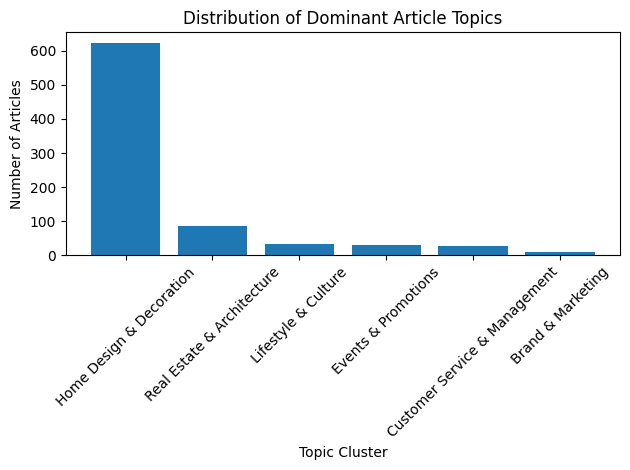

In [6]:
import matplotlib.pyplot as plt
import os
os.chdir(r"C:\Users\wangy")
df= pd.read_excel("batch_outputs(S2)/filtered2_results_clustered_all(translated).xlsx")
# Count values
cluster_counts = df["TopContentCluster"].value_counts()

# Plot
plt.figure()
plt.bar(cluster_counts.index, cluster_counts.values)

plt.xlabel("Topic Cluster")
plt.ylabel("Number of Articles")
plt.title("Distribution of Dominant Article Topics")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()